# Phân tích và dự đoán xu hướng tuyển dụng IT tại Việt Nam

Notebook tái sử dụng được với `jobs_raw.csv`; nếu file này chưa có, notebook tự dùng dữ liệu ETL của dự án tại `data/processed/jobs_cleaned_full.csv`. Chạy các cell theo thứ tự từ trên xuống.

In [1]:
from pathlib import Path
import json
import re
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
ARTIFACT_DIR = PROJECT_ROOT / 'reports' / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
print(f'Project root: {PROJECT_ROOT}')

Project root: C:\Users\admin\Documents\job_prediction


## 1. Load dataset

In [2]:
def find_dataset(root: Path) -> Path:
    candidates = [root / 'jobs_raw.csv', root / 'data' / 'raw' / 'jobs_raw.csv',
                  root / 'data' / 'processed' / 'jobs_cleaned_full.csv']
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError('Không tìm thấy jobs_raw.csv hoặc data/processed/jobs_cleaned_full.csv. Hãy thêm một trong hai file.')

DATA_PATH = find_dataset(PROJECT_ROOT)
raw = pd.read_csv(DATA_PATH)
# Ánh xạ schema crawler/ETL về schema chuẩn của notebook.
ALIASES = {'job_title': 'title', 'company_name': 'company', 'salary_min': 'salary_min_vnd',
           'salary_max': 'salary_max_vnd', 'experience_required': 'experience', 'skills': 'skills_existing'}
raw = raw.rename(columns={old: new for old, new in ALIASES.items() if old in raw.columns and new not in raw.columns})
required = {'title', 'location'}
missing = required - set(raw.columns)
if missing:
    raise ValueError(f'Thiếu cột bắt buộc: {sorted(missing)}. Cần tối thiểu title và location.')
for col in ['company', 'salary', 'salary_min_vnd', 'salary_max_vnd', 'experience', 'job_level', 'description', 'posted_date', 'source', 'skills_existing']:
    if col not in raw.columns:
        raw[col] = np.nan
print(f'Loaded {DATA_PATH.relative_to(PROJECT_ROOT)}: {raw.shape[0]:,} rows × {raw.shape[1]} columns')
display(raw.head())
display(raw.isna().sum().sort_values(ascending=False).to_frame('missing_values'))

Loaded data\processed\jobs_cleaned_full.csv: 5,717 rows × 15 columns


,title,company,location,posted_date,salary_min_vnd,salary_max_vnd,salary_currency,job_type,job_level,experience,skills_existing,source,salary_missing,salary,description
0,AI/ML Engineer,Ngân Hàng TMCP Việt Nam Thịnh Vượng - VPBANK,Hanoi,2026-06-15,NaN,NaN,NaN,Full-time,NaN,2.0,NaN,careerviet,True,NaN,NaN
1,QA/Tester,OMN1 Solution,Ho Chi Minh City,2026-06-15,NaN,NaN,NaN,Full-time,NaN,2.0,NaN,careerviet,True,NaN,NaN
2,Product Manager/Owner,CÔNG TY LIÊN DOANH VẬN CHUYỂN QUỐC TẾ HẢI VÂN,Hanoi,2026-06-15,25000000.0,40000000.0,VND,Full-time,NaN,2.0,NaN,careerviet,False,NaN,NaN
3,Data Analyst,Nova Service Group - Công ty Cổ phần Tập đoàn ...,Ho Chi Minh City,2026-06-15,20000000.0,35000000.0,VND,Full-time,NaN,5.0,NaN,careerviet,False,NaN,NaN
4,QA/Tester,Ngân Hàng TMCP Sài Gòn - Hà Nội ( SHB ),Hanoi,2026-06-15,NaN,NaN,NaN,Full-time,NaN,3.0,NaN,careerviet,True,NaN,NaN


,missing_values
salary,5717
description,5717
salary_min_vnd,3604
salary_max_vnd,3402
salary_currency,3348
skills_existing,1816
job_level,938
experience,727
posted_date,1
location,0


## 2. Data cleaning

In [3]:
def clean_text(text):
    return '' if pd.isna(text) else re.sub(r'\s+', ' ', str(text)).strip()

def parse_salary_to_vnd(salary_text):
    """Return (min_vnd, max_vnd); supports USD, triệu/million, up to and negotiable."""
    text = clean_text(salary_text).lower().replace(',', '')
    if not text or any(x in text for x in ['negotiable', 'thỏa thuận', 'thoả thuận', 'competitive']):
        return (np.nan, np.nan)
    values = [float(x) for x in re.findall(r'\d+(?:\.\d+)?', text)]
    if not values:
        return (np.nan, np.nan)
    multiplier = 25_000_000 if 'usd' in text or '$' in text else (1_000_000 if any(x in text for x in ['triệu', 'trieu', 'million', 'm ']) else 1)
    values = [v * multiplier for v in values[:2]]
    if 'up to' in text or 'tối đa' in text:
        return (np.nan, values[0])
    return (values[0], values[-1]) if len(values) > 1 else (values[0], values[0])

def parse_experience(exp_text):
    text = clean_text(exp_text).lower()
    if any(x in text for x in ['intern', 'thực tập']): return 0.0
    if any(x in text for x in ['fresher', 'fresh graduate', 'new graduate']): return 0.5
    nums = [float(x) for x in re.findall(r'\d+(?:\.\d+)?', text)]
    return np.mean(nums[:2]) if nums else np.nan

def normalize_location(location):
    text = clean_text(location).lower()
    if any(x in text for x in ['hồ chí minh', 'ho chi minh', 'hcm', 'sài gòn', 'sai gon']): return 'Ho Chi Minh City'
    if any(x in text for x in ['hà nội', 'ha noi', 'hanoi']): return 'Hanoi'
    if any(x in text for x in ['đà nẵng', 'da nang']): return 'Da Nang'
    if 'remote' in text: return 'Remote'
    return 'Other'

def normalize_job_title(title):
    text = clean_text(title).lower()
    rules = [('Data Engineer', r'data engineer|etl|data pipeline'), ('AI/ML Engineer', r'\b(ai|ml)\b|machine learning|data scientist|nlp'),
             ('Data Analyst', r'data analyst|bi analyst|business intelligence'), ('DevOps/Infra Engineer', r'devops|sre|infrastructure'),
             ('Frontend Developer', r'front[ -]?end|react|angular|vue'), ('Backend Developer', r'back[ -]?end|java|\.net|php|node\.?js'),
             ('Mobile Developer', r'android|ios|flutter|react native'), ('QA/Tester', r'\bqa\b|tester|testing'),
             ('Project Manager', r'project manager|scrum master'), ('Business Analyst', r'business analyst'),
             ('Security Engineer', r'security|cyber'), ('Fullstack/Software Engineer', r'full[ -]?stack|software|developer|engineer')]
    return next((group for group, pattern in rules if re.search(pattern, text)), 'Other')

df = raw.copy()
parsed_salary = df['salary'].apply(parse_salary_to_vnd)
for i, col in enumerate(['salary_min_vnd', 'salary_max_vnd']):
    parsed = parsed_salary.str[i]
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(parsed)
df['salary_avg_vnd'] = df[['salary_min_vnd', 'salary_max_vnd']].mean(axis=1)
df['experience_years'] = df['experience'].apply(parse_experience)
df['location_norm'] = df['location'].apply(normalize_location)
df['job_title_group'] = df['title'].apply(normalize_job_title)
df['description_clean'] = df['description'].apply(clean_text)
df['posted_date'] = pd.to_datetime(df['posted_date'], errors='coerce')
display(df[['salary_min_vnd', 'salary_max_vnd', 'salary_avg_vnd', 'experience_years', 'location_norm', 'job_title_group']].head())

,salary_min_vnd,salary_max_vnd,salary_avg_vnd,experience_years,location_norm,job_title_group
0,NaN,NaN,NaN,2.0,Hanoi,AI/ML Engineer
1,NaN,NaN,NaN,2.0,Ho Chi Minh City,QA/Tester
2,25000000.0,40000000.0,32500000.0,2.0,Hanoi,Other
3,20000000.0,35000000.0,27500000.0,5.0,Ho Chi Minh City,Data Analyst
4,NaN,NaN,NaN,3.0,Hanoi,QA/Tester


## 3. Skill extraction and multi-hot features

In [4]:
SKILLS = ['Python', 'Java', 'JavaScript', 'TypeScript', 'React', 'Vue', 'Angular', 'Node.js', 'Express', 'SQL', 'MySQL', 'PostgreSQL', 'MongoDB', 'Redis', 'Docker', 'Kubernetes', 'AWS', 'Azure', 'GCP', 'Linux', 'Git', 'CI/CD', 'Machine Learning', 'Deep Learning', 'NLP', 'Computer Vision', 'Data Analysis', 'Data Engineering', 'Spark', 'Hadoop', 'Airflow', 'Kafka', 'Power BI', 'Tableau', 'Excel', 'C++', 'C#', 'PHP', 'Laravel', 'Django', 'Flask', 'FastAPI', 'Spring Boot', 'Android', 'iOS', 'Flutter', 'DevOps', 'Security', 'Testing', 'QA', 'TensorFlow', 'PyTorch', 'Terraform', 'Jenkins', 'GraphQL', 'HTML', 'CSS', 'Go', 'Ruby', 'Scala', 'R', 'Selenium']
SKILL_PATTERNS = {skill: re.compile(r'(?<![\w+#.])' + re.escape(skill).replace(r'\ ', r'\s*') + r'(?![\w+#.])', re.I) for skill in SKILLS}
SKILL_PATTERNS.update({'Node.js': re.compile(r'\b(node\.?js|nodejs)\b', re.I), 'Vue': re.compile(r'\b(vue\.?js|vuejs|vue)\b', re.I), 'CI/CD': re.compile(r'\b(ci/cd|cicd)\b', re.I), 'C#': re.compile(r'c#|csharp', re.I), 'C++': re.compile(r'c\+\+|cpp', re.I)})
def extract_skills(description):
    text = clean_text(description)
    return [skill for skill, pattern in SKILL_PATTERNS.items() if pattern.search(text)]

def parse_existing_skills(value):
    if pd.isna(value): return []
    text = str(value)
    return [skill for skill in SKILLS if re.search(r'(?<!\w)' + re.escape(skill) + r'(?!\w)', text, re.I)]

df['skills_extracted'] = df.apply(lambda row: extract_skills(row['description_clean']) or parse_existing_skills(row['skills_existing']), axis=1)
df['num_skills'] = df['skills_extracted'].str.len()
# Slug rõ nghĩa, bảo đảm duy nhất (đặc biệt C++ và C#).
SKILL_SLUGS = {'C++': 'c_plus_plus', 'C#': 'c_sharp'}
skill_columns = []
for skill in SKILLS:
    col = 'skill_' + SKILL_SLUGS.get(skill, re.sub(r'[^a-z0-9]+', '_', skill.lower()).strip('_'))
    df[col] = df['skills_extracted'].apply(lambda found, s=skill: int(s in found))
    skill_columns.append(col)
print(f'{len(SKILLS)} skills configured; {df.num_skills.gt(0).sum():,} jobs contain extracted skills.')
with open(ARTIFACT_DIR / 'skill_dictionary.json', 'w', encoding='utf-8') as f:
    json.dump({'skills': SKILLS}, f, ensure_ascii=False, indent=2)

62 skills configured; 2,713 jobs contain extracted skills.


## 4. Exploratory data analysis

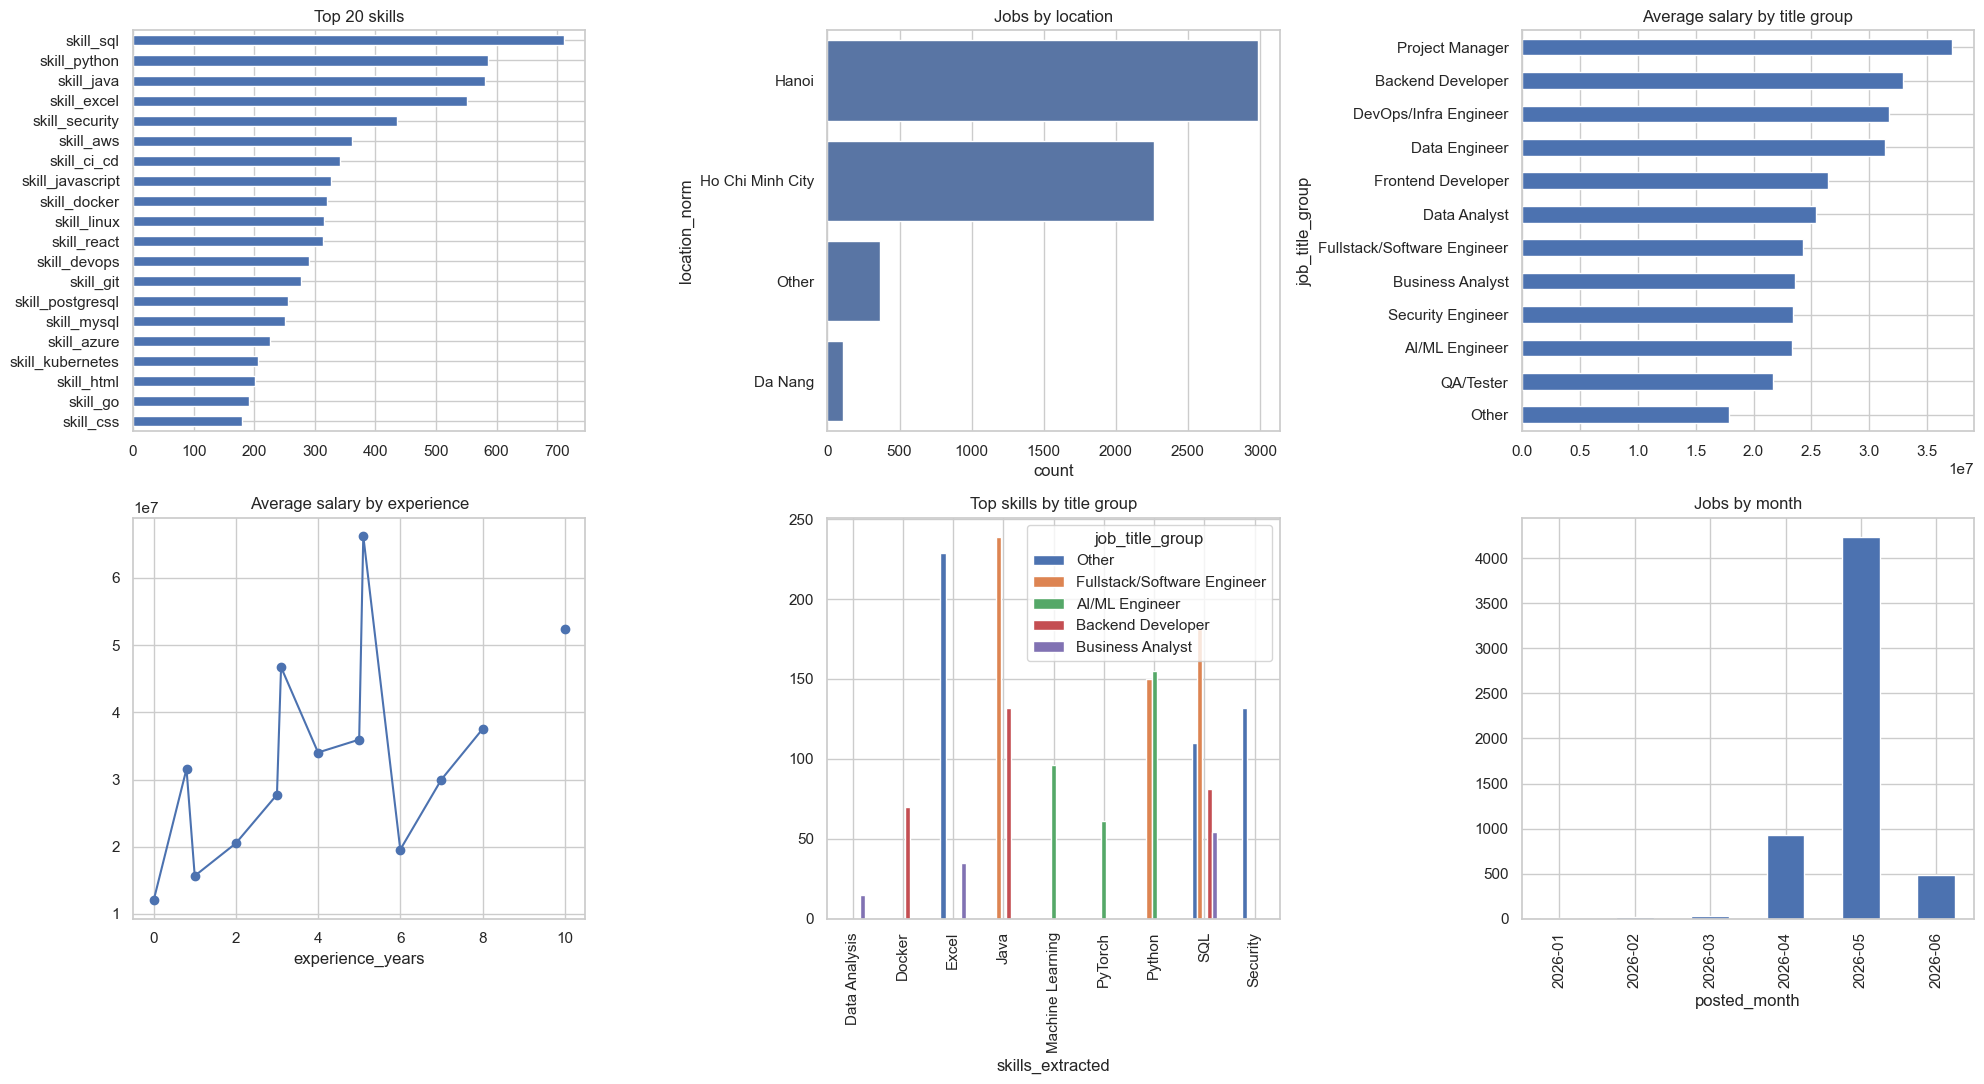

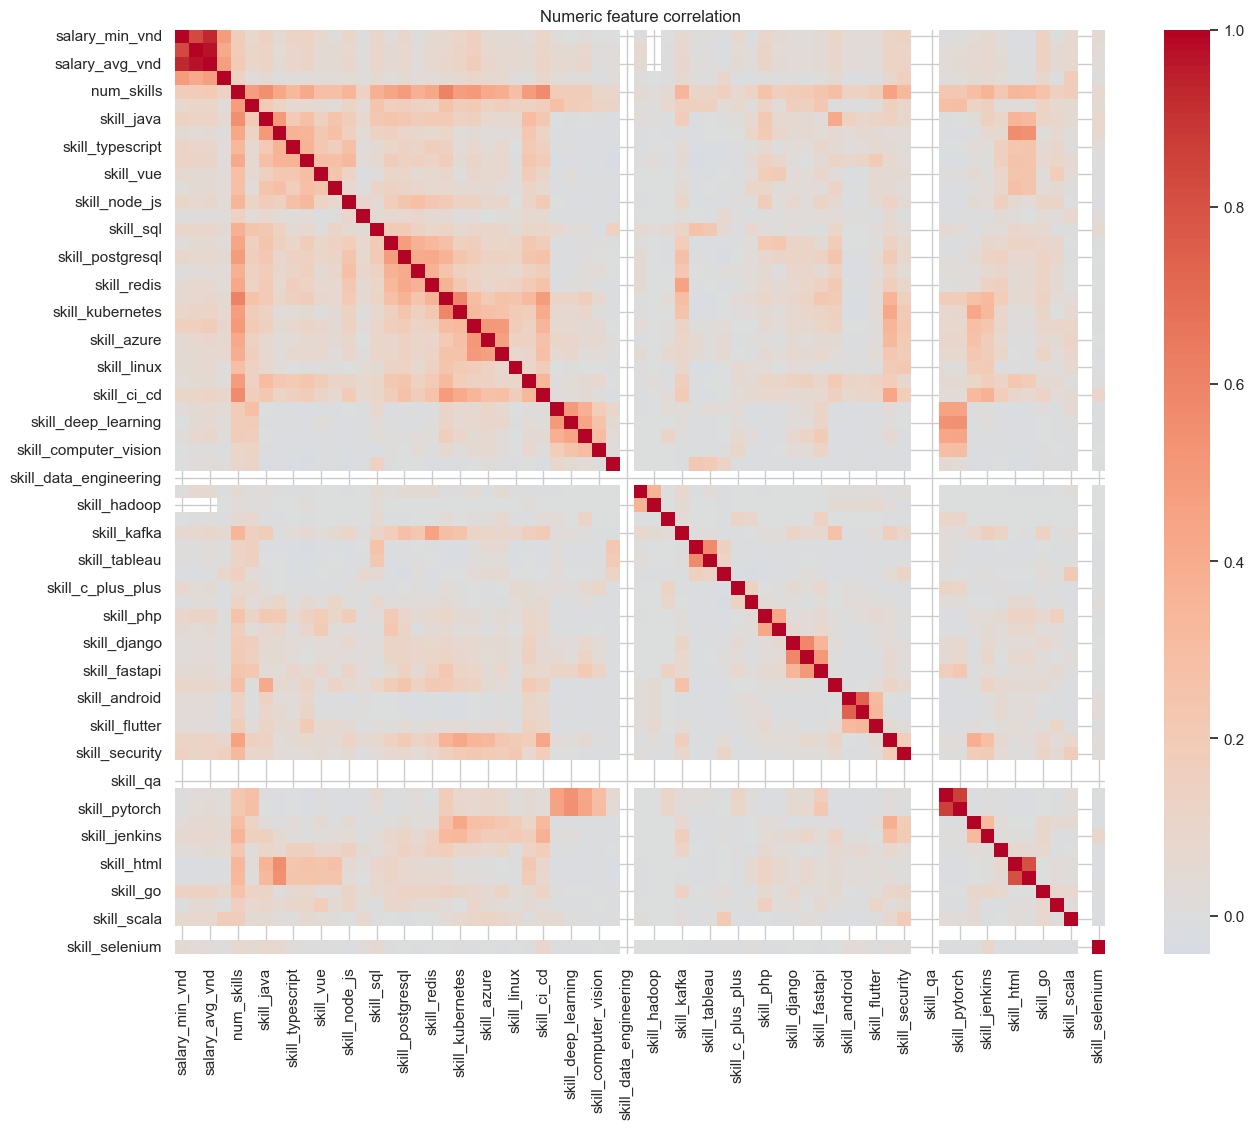

In [5]:
skill_counts = df[skill_columns].sum().sort_values(ascending=False)
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
skill_counts.head(20).sort_values().plot.barh(ax=axes[0,0], title='Top 20 skills')
sns.countplot(data=df, y='location_norm', order=df['location_norm'].value_counts().index, ax=axes[0,1]); axes[0,1].set_title('Jobs by location')
df.groupby('job_title_group')['salary_avg_vnd'].mean().sort_values().plot.barh(ax=axes[0,2], title='Average salary by title group')
df.groupby('experience_years')['salary_avg_vnd'].mean().sort_index().plot(kind='line', marker='o', ax=axes[1,0], title='Average salary by experience')
top_groups = df['job_title_group'].value_counts().head(5).index
role_skill = df[['job_title_group', 'skills_extracted']].explode('skills_extracted').dropna(subset=['skills_extracted'])
pd.crosstab(role_skill['job_title_group'], role_skill['skills_extracted']).reindex(top_groups).T.apply(lambda x: x.nlargest(3)).dropna(how='all').plot.bar(ax=axes[1,1], title='Top skills by title group')
df['posted_month'] = df['posted_date'].dt.to_period('M').astype(str).replace('NaT', np.nan)
df['posted_month'].value_counts().sort_index().plot.bar(ax=axes[1,2], title='Jobs by month')
plt.tight_layout(); plt.show()
numeric_cols = ['salary_min_vnd', 'salary_max_vnd', 'salary_avg_vnd', 'experience_years', 'num_skills'] + skill_columns
plt.figure(figsize=(15, 12)); sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', center=0); plt.title('Numeric feature correlation'); plt.show()

## 5. Salary prediction: training, evaluation and K-fold validation

,model,MAE,RMSE,R2
0,XGBoost,"7,845,569","13,381,712",0.218
1,Linear Regression,"8,227,935","13,449,875",0.210


5-fold CV — MAE: 7,813,355 ± 246,586; R²: 0.283 ± 0.050


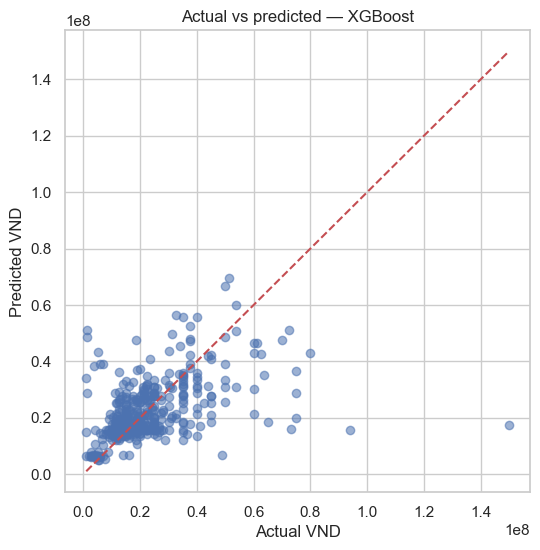

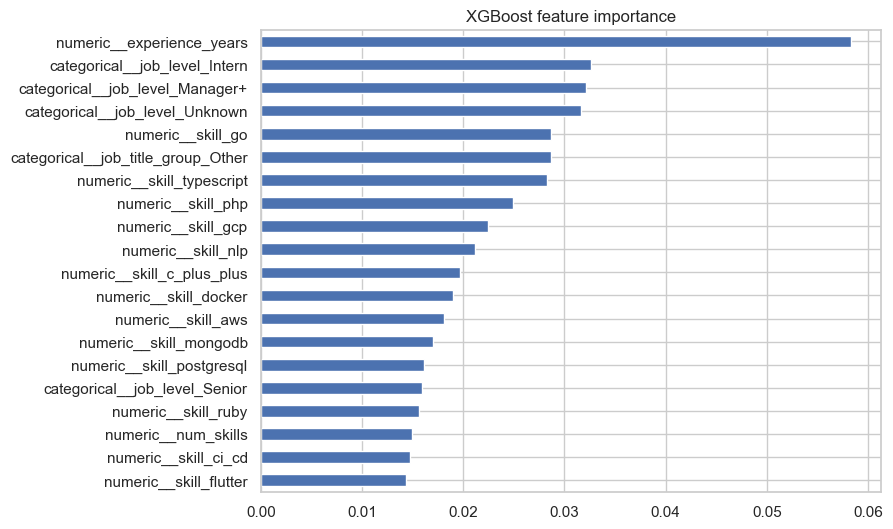

['C:\\Users\\admin\\Documents\\job_prediction\\reports\\artifacts\\feature_columns.pkl']

In [6]:
feature_cols = ['experience_years', 'num_skills', 'location_norm', 'job_level', 'job_title_group'] + skill_columns
model_df = df.dropna(subset=['salary_avg_vnd']).copy()
if len(model_df) < 30:
    raise ValueError(f'Cần ít nhất 30 dòng có salary_avg_vnd để train; hiện có {len(model_df)}.')
model_df['experience_years'] = model_df['experience_years'].fillna(model_df['experience_years'].median())
model_df['job_level'] = model_df['job_level'].fillna('Unknown').astype(str)
X, y = model_df[feature_cols], model_df['salary_avg_vnd']
cat_cols = ['location_norm', 'job_level', 'job_title_group']
num_cols = [c for c in feature_cols if c not in cat_cols]
preprocessor = ColumnTransformer([('categorical', OneHotEncoder(handle_unknown='ignore'), cat_cols), ('numeric', 'passthrough', num_cols)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
models = {'Linear Regression': LinearRegression(), 'XGBoost': XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, objective='reg:squarederror')}
pipelines, rows = {}, []
for name, estimator in models.items():
    pipe = Pipeline([('preprocessor', clone(preprocessor)), ('model', estimator)])
    pipe.fit(X_train, y_train); pred = pipe.predict(X_test); pipelines[name] = pipe
    rows.append({'model': name, 'MAE': mean_absolute_error(y_test, pred), 'RMSE': np.sqrt(mean_squared_error(y_test, pred)), 'R2': r2_score(y_test, pred)})
evaluation = pd.DataFrame(rows).sort_values('MAE').reset_index(drop=True)
best_name = evaluation.loc[0, 'model']; best_pipeline = pipelines[best_name]; best_pred = best_pipeline.predict(X_test)
display(evaluation.style.format({'MAE': '{:,.0f}', 'RMSE': '{:,.0f}', 'R2': '{:.3f}'}))
evaluation.to_csv(ARTIFACT_DIR / 'model_evaluation_report.csv', index=False)
cv = KFold(n_splits=min(5, len(model_df)), shuffle=True, random_state=RANDOM_STATE)
cv_result = cross_validate(best_pipeline, X, y, cv=cv, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})
print(f'5-fold CV — MAE: {-cv_result["test_mae"].mean():,.0f} ± {cv_result["test_mae"].std():,.0f}; R²: {cv_result["test_r2"].mean():.3f} ± {cv_result["test_r2"].std():.3f}')
plt.figure(figsize=(6, 6)); plt.scatter(y_test, best_pred, alpha=.55); lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]; plt.plot(lims, lims, 'r--'); plt.xlabel('Actual VND'); plt.ylabel('Predicted VND'); plt.title(f'Actual vs predicted — {best_name}'); plt.show()
if best_name == 'XGBoost':
    names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
    importance = pd.Series(best_pipeline.named_steps['model'].feature_importances_, index=names).nlargest(20).sort_values()
    importance.plot.barh(figsize=(8, 6), title='XGBoost feature importance'); plt.show()
joblib.dump(best_pipeline, ARTIFACT_DIR / 'salary_prediction_model.pkl')
joblib.dump(best_pipeline.named_steps['preprocessor'], ARTIFACT_DIR / 'preprocessor.pkl')
joblib.dump(feature_cols, ARTIFACT_DIR / 'feature_columns.pkl')

## 6. Skill trend analysis and 1–3 month forecast

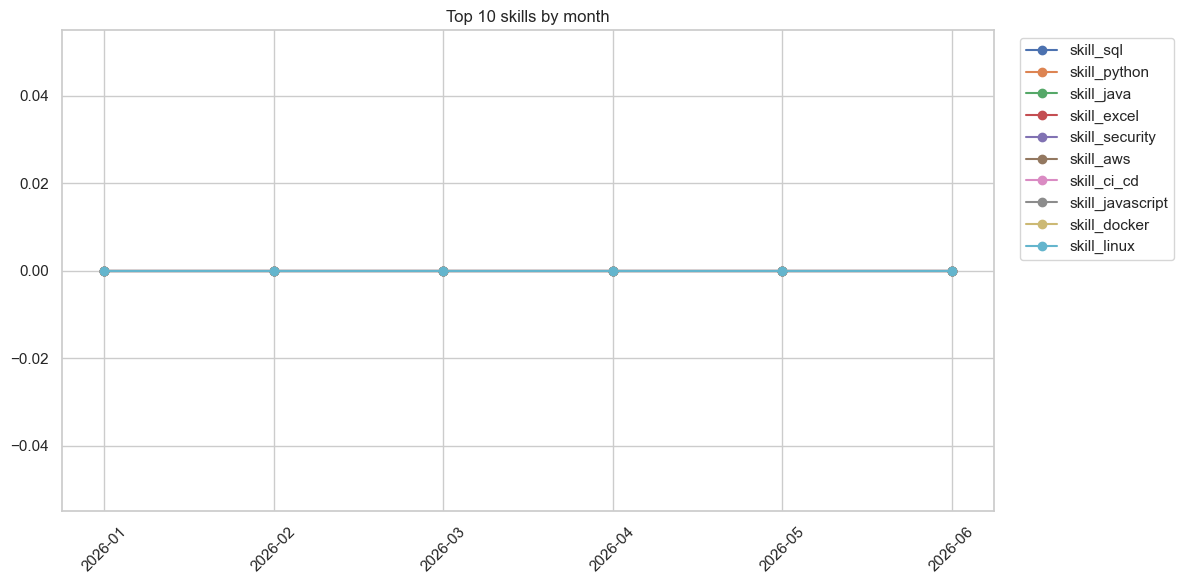

,skill,current_month_count,forecast_next_1_month,forecast_next_2_month,forecast_next_3_month,growth_rate,trend_label
0,skill_sql,0,0.0,0.0,0.0,0.0%,Stable
1,skill_python,0,0.0,0.0,0.0,0.0%,Stable
2,skill_java,0,0.0,0.0,0.0,0.0%,Stable
3,skill_excel,0,0.0,0.0,0.0,0.0%,Stable
4,skill_security,0,0.0,0.0,0.0,0.0%,Stable
5,skill_aws,0,0.0,0.0,0.0,0.0%,Stable
6,skill_ci_cd,0,0.0,0.0,0.0,0.0%,Stable
7,skill_javascript,0,0.0,0.0,0.0,0.0%,Stable
8,skill_docker,0,0.0,0.0,0.0,0.0%,Stable
9,skill_linux,0,0.0,0.0,0.0,0.0%,Stable


In [7]:
skill_month = (df.dropna(subset=['posted_month']).explode('skills_extracted').dropna(subset=['skills_extracted'])
               .groupby(['skills_extracted', 'posted_month']).size().rename('job_count').reset_index().rename(columns={'skills_extracted': 'skill'}))
all_months = pd.period_range(df['posted_date'].min().to_period('M'), df['posted_date'].max().to_period('M'), freq='M').astype(str) if df['posted_date'].notna().any() else []
top10 = skill_counts.head(10).index.tolist()
plt.figure(figsize=(12, 6))
for skill in top10:
    series = skill_month[skill_month.skill.eq(skill)].set_index('posted_month').reindex(all_months, fill_value=0)['job_count']
    plt.plot(series.index, series.values, marker='o', label=skill)
plt.title('Top 10 skills by month'); plt.xticks(rotation=45); plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left'); plt.tight_layout(); plt.show()
forecasts = []
for skill in top10:
    series = skill_month[skill_month.skill.eq(skill)].set_index('posted_month').reindex(all_months, fill_value=0)['job_count'].astype(float)
    current = series.iloc[-1] if len(series) else 0
    growth = ((current - series.iloc[-2]) / series.iloc[-2]) if len(series) > 1 and series.iloc[-2] else 0.0
    if len(series) >= 2:
        coef, intercept = np.polyfit(np.arange(len(series)), series.values, 1); future = [max(0, coef * (len(series) + i) + intercept) for i in range(3)]
    else:
        future = [current] * 3
    label = 'Hot' if growth > .10 else ('Declining' if growth < -.10 else 'Stable')
    forecasts.append({'skill': skill, 'current_month_count': current, 'forecast_next_1_month': future[0], 'forecast_next_2_month': future[1], 'forecast_next_3_month': future[2], 'growth_rate': growth, 'trend_label': label})
forecast_df = pd.DataFrame(forecasts).sort_values('forecast_next_1_month', ascending=False)
forecast_df.to_csv(ARTIFACT_DIR / 'skill_trend_forecast.csv', index=False)
display(forecast_df.style.format({'current_month_count': '{:.0f}', 'forecast_next_1_month': '{:.1f}', 'forecast_next_2_month': '{:.1f}', 'forecast_next_3_month': '{:.1f}', 'growth_rate': '{:.1%}'}))

## 7. Inference demo and final summary

In [8]:
def predict_salary(title, location, experience, job_level, description):
    """Return a salary prediction in VND using the saved reusable pipeline."""
    found = extract_skills(description)
    row = {'experience_years': parse_experience(experience), 'num_skills': len(found), 'location_norm': normalize_location(location), 'job_level': clean_text(job_level) or 'Unknown', 'job_title_group': normalize_job_title(title)}
    row['experience_years'] = row['experience_years'] if pd.notna(row['experience_years']) else model_df['experience_years'].median()
    for skill, col in zip(SKILLS, skill_columns): row[col] = int(skill in found)
    model = joblib.load(ARTIFACT_DIR / 'salary_prediction_model.pkl')
    return float(model.predict(pd.DataFrame([row])[feature_cols])[0])

demo = predict_salary('Python Backend Developer', 'Ho Chi Minh City', '3 years', 'Mid', 'Python, FastAPI, PostgreSQL, Docker, AWS')
print(f'Demo predicted salary: {demo:,.0f} VND')
print(f'Best model: {best_name}')
display(evaluation.head(1))
print('Top 10 skills:', ', '.join(top10))
print('Fastest growing skills:', ', '.join(forecast_df.sort_values('growth_rate', ascending=False).head(10)['skill']))
print('Nhận xét: kết quả phản ánh các tin có công bố lương trong tập dữ liệu; cần thu thập đều qua nhiều tháng để kết luận xu hướng thị trường đáng tin cậy hơn.')

Demo predicted salary: 27,350,100 VND
Best model: XGBoost


,model,MAE,RMSE,R2
0,XGBoost,7.845569e+06,1.338171e+07,0.218189


Top 10 skills: skill_sql, skill_python, skill_java, skill_excel, skill_security, skill_aws, skill_ci_cd, skill_javascript, skill_docker, skill_linux
Fastest growing skills: skill_sql, skill_python, skill_java, skill_excel, skill_security, skill_aws, skill_ci_cd, skill_javascript, skill_docker, skill_linux
Nhận xét: kết quả phản ánh các tin có công bố lương trong tập dữ liệu; cần thu thập đều qua nhiều tháng để kết luận xu hướng thị trường đáng tin cậy hơn.


## Production artifacts
Cell này dùng chính module vận hành của hệ thống (không dùng lại logic notebook).

In [ ]:
import sys
from pathlib import Path
project_root = Path.cwd().resolve()
if not (project_root / 'src').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.models.salary_predictor import train_salary_model, predict_salary as production_predict_salary
from src.analytics.trends import build_analytics

# Chỉ bỏ comment khi muốn tái tạo artifacts giống CLI scripts/run_modeling.py và run_analytics.py.
# _, production_report, production_metadata = train_salary_model()
# production_summary, production_history, production_forecast = build_analytics()

production_prediction = production_predict_salary('Python Backend Developer', 'Ho Chi Minh City', '3 years', 'Mid', 'Python, FastAPI, PostgreSQL, Docker, AWS')
production_prediction